In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\hp\Desktop\changes\sales-data-analysis\data\sales_summary.csv")

df.head(10)

,Date,Time,Item_Code,Item_Name,Category_Name,Quantity_Sold_kilo,Unit_Selling_Price_RMB_kg,Wholesale_Price_RMB_kg,Loss_Rate,Discount_Yes_No,revenue,profit
0,9/7/2020,26:52.0,102900005119975,Hongshujian,Flower/LeafÂ Vegetables,0.60,4.0,2.40,8.42,No,2.400,0.9600
1,9/7/2020,26:53.6,102900005116509,Green Eggplant (1),Solanum,0.38,8.0,5.18,5.01,No,3.040,1.0716
2,9/7/2020,27:21.1,102900051010455,Huangbaicai (2),Flower/LeafÂ Vegetables,0.39,6.0,3.63,15.61,No,2.340,0.9243
3,9/7/2020,27:21.3,102900005125815,Apricot Bao Mushroom (1),Edible Mushroom,0.32,12.0,7.06,5.05,No,3.840,1.5808
4,9/7/2020,28:15.2,102900005116943,Red Hang Pepper,Capsicum,0.12,14.0,7.07,9.99,No,1.680,0.8316
5,9/7/2020,28:19.9,102900051004294,Green Line Pepper,Capsicum,0.18,8.6,5.14,7.80,No,1.548,0.6228
6,9/7/2020,28:40.9,102900005115779,Yunnan Shengcai,Flower/LeafÂ Vegetables,0.46,9.0,4.43,15.25,No,4.140,2.1022
7,9/7/2020,29:57.7,102900011009970,Qinggengsanhua,Cabbage,0.60,10.0,4.83,17.06,No,6.000,3.1020
8,9/7/2020,29:58.0,102900005115823,Shanghaiqing,Flower/LeafÂ Vegetables,0.94,9.6,5.31,14.43,No,9.024,4.0326
9,9/7/2020,30:29.7,102900005116233,Red Pepper (1),Capsicum,0.11,9.0,4.82,11.76,No,0.990,0.4598


df.shape

## Check Null Value

In [11]:
df.isnull().sum()

Date                         0
Time                         0
Item_Code                    0
Item_Name                    0
Category_Name                0
Quantity_Sold_kilo           0
Unit_Selling_Price_RMB_kg    0
Wholesale_Price_RMB_kg       0
Loss_Rate                    0
Discount_Yes_No              0
revenue                      0
profit                       0
dtype: int64

## Checke Duplicates

In [13]:
df.duplicated().sum()

np.int64(215)

## Remove Deuplicated

In [18]:
df_Cleaned = df.drop_duplicates()


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878503 entries, 0 to 878502
Data columns (total 12 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Date                       878503 non-null  object 
 1   Time                       878503 non-null  object 
 2   Item_Code                  878503 non-null  int64  
 3   Item_Name                  878503 non-null  object 
 4   Category_Name              878503 non-null  object 
 5   Quantity_Sold_kilo         878503 non-null  float64
 6   Unit_Selling_Price_RMB_kg  878503 non-null  float64
 7   Wholesale_Price_RMB_kg     878503 non-null  float64
 8   Loss_Rate                  878503 non-null  float64
 9   Discount_Yes_No            878503 non-null  object 
 10  revenue                    878503 non-null  float64
 11  profit                     878503 non-null  float64
dtypes: float64(6), int64(1), object(5)
memory usage: 80.4+ MB


In [31]:
df['Date'] = pd.to_datetime(df['Date'])

## Exploratory Data Analysis (EDA)

### <span style="color: #c0392b; padding: 4px 8px; border-radius: 4px;">1. revenue over time</span>

In [33]:
Revenue_Date = df.groupby('Date')['revenue'].sum()
Revenue_Date

Date
2020-07-01    3476.664
2020-07-02    3459.324
2020-07-03    3388.156
2020-07-04    4400.004
2020-07-05    4475.088
                ...   
2023-06-26    1509.998
2023-06-27    1761.071
2023-06-28    1824.756
2023-06-29    2200.206
2023-06-30    2233.247
Name: revenue, Length: 1085, dtype: float64

In [43]:
# Weekly (smoother, better for trend spotting)
weekly = df.set_index('Date').resample('W')['revenue'].sum()
daily_revenue = df.groupby('Date')['revenue'].sum()

In [44]:
rolling = weekly.rolling(window=4).mean()

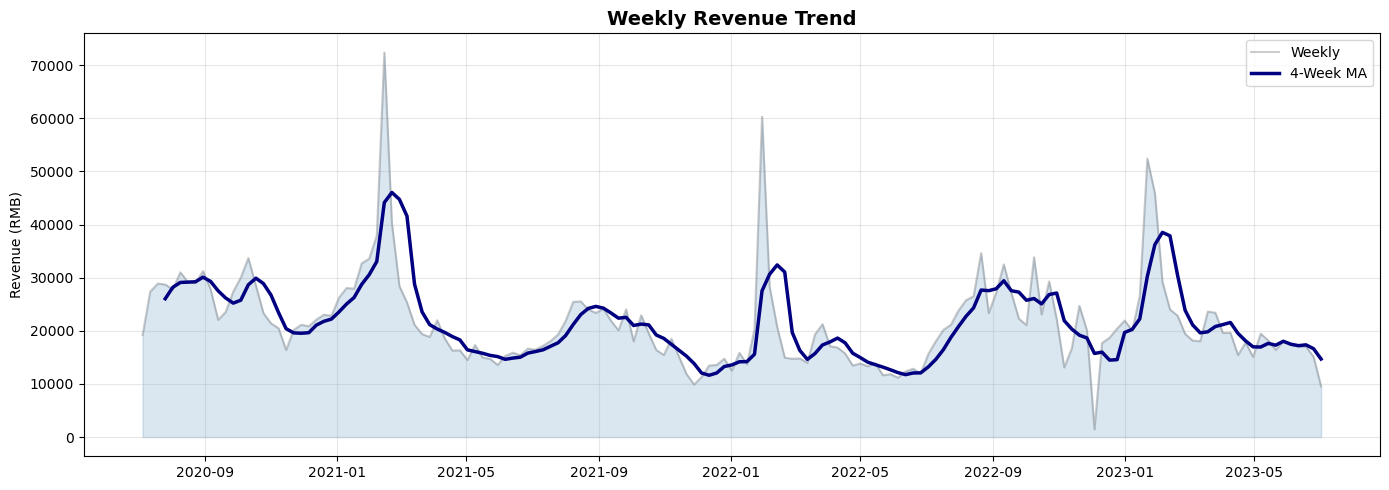

In [45]:
plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly.values, alpha=0.4, color='gray', label='Weekly')
plt.plot(rolling.index, rolling.values, color='navy', linewidth=2.5, label='4-Week MA')
plt.fill_between(weekly.index, weekly.values, alpha=0.2, color='steelblue')
plt.title('Weekly Revenue Trend', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (RMB)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### <span style="color: #c0392b; padding: 4px 8px; border-radius: 4px;">2. Top Categories by Revenue</span>

In [83]:
Top_Category= df.groupby('Category_Name')['revenue'].sum().sort_values(ascending=False)
Top_Category

Category_Name
Flower/LeafÂ Vegetables        1079467.885
Capsicum                        754835.286
Edible Mushroom                 620130.465
Cabbage                         375834.553
Aquatic Tuberous Vegetables     350193.969
Solanum                         191170.310
Name: revenue, dtype: float64

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Flower/LeafÂ\xa0Vegetables'),
  Text(1, 0, 'Capsicum'),
  Text(2, 0, 'Edible Mushroom'),
  Text(3, 0, 'Cabbage'),
  Text(4, 0, 'Aquatic Tuberous Vegetables'),
  Text(5, 0, 'Solanum')])

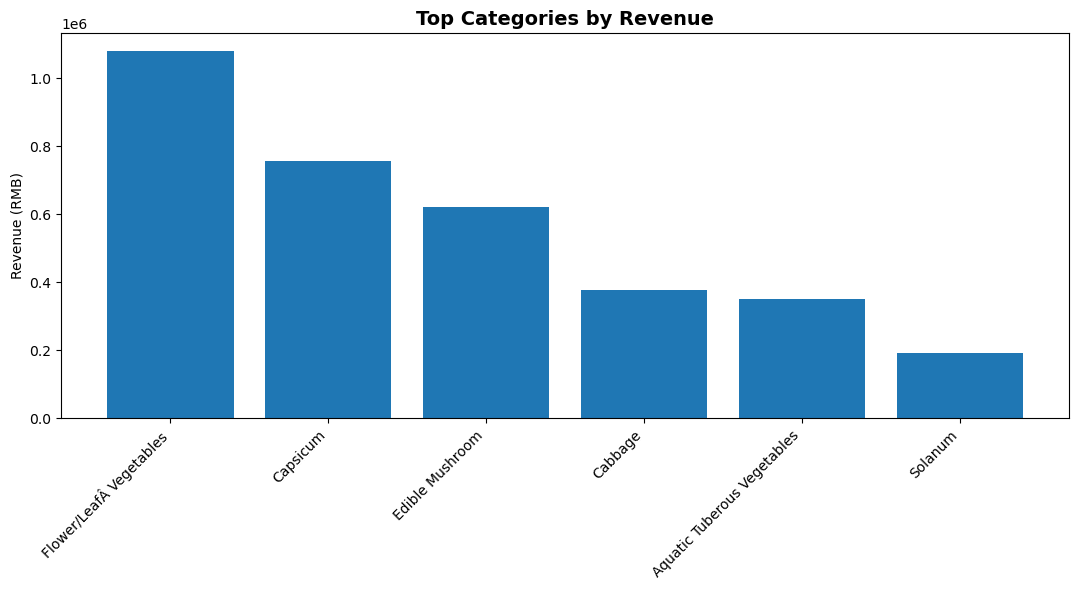

In [84]:
plt.figure(figsize=(13, 5))
plt.bar(Top_Category.index, Top_Category.values)
plt.title('Top Categories by Revenue', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (RMB)')
plt.xticks(rotation=45, ha='right')

### <span style="color: #c0392b; padding: 4px 8px; border-radius: 4px;">3. Top Products by Profit</span>

In [81]:
Top_Product = df.groupby('Item_Name')['profit'].sum().sort_values(ascending=False)
top_10 = Top_Product.head(10)
top_10

Item_Name
Broccoli                 90150.3428
Xixia Mushroom (1)       71598.5741
Net Lotus Root (1)       62352.7822
Wuhu Green Pepper (1)    61435.5424
Yunnan Shengcai          50004.5550
Eggplant (2)             40131.9720
Luosi Pepper             28202.7460
Yunnan Lettuces          27900.9450
Millet Pepper (Bag)      27316.1900
Paopaojiao (Jingpin)     25963.2686
Name: profit, dtype: float64

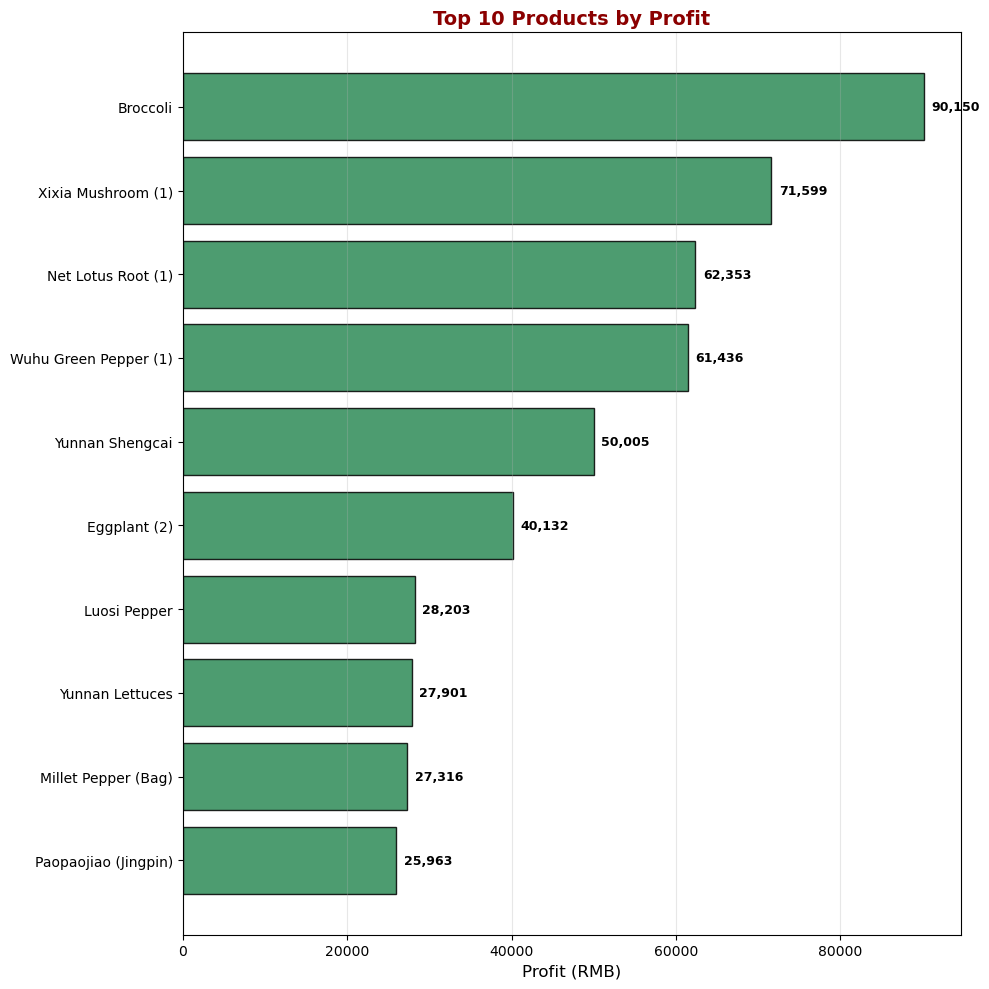

In [82]:
# 2. Horizontal bar chart (names read left-to-right)
plt.figure(figsize=(10, 10))
colors = ['seagreen' if v > 0 else 'crimson' for v in top_10.values]
bars = plt.barh(range(len(top_20)), top_20.values, color=colors, edgecolor='black', alpha=0.85)

# 3. Add product names on y-axis
plt.yticks(range(len(top_10)), top_10.index, fontsize=10)
plt.gca().invert_yaxis()  # #1 at the top

# 4. Add value labels on each bar
for i, (bar, val) in enumerate(zip(bars, top_20.values)):
    plt.text(val + max(top_10.values)*0.01, i, f'{val:,.0f}', 
             va='center', fontsize=9, fontweight='bold')

plt.title('Top 10 Products by Profit', fontsize=14, fontweight='bold', color='darkred')
plt.xlabel('Profit (RMB)', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### <span style="color: #c0392b; padding: 4px 8px; border-radius: 4px;">4. Profit vs Loss Rate</span>

In [21]:
Profit_Loss = df.groupby('Item_Name')[['profit', 'Loss_Rate']].mean()


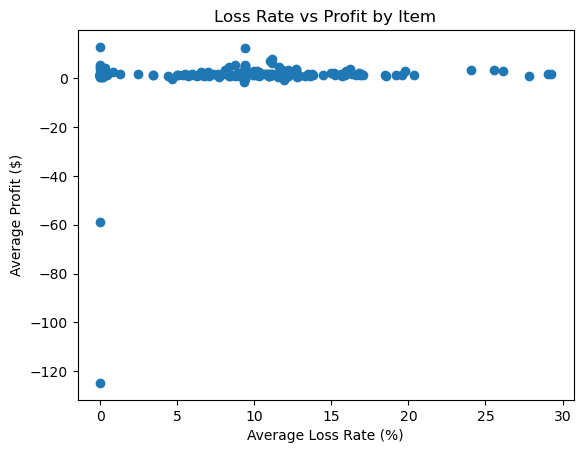

In [22]:
# 2. Pull x and y from the SAME new grouped data
x = Profit_Loss['Loss_Rate']
y = Profit_Loss['profit']

# 3. Plot it (They are now the exact same size!)
plt.scatter(x, y)
plt.xlabel('Average Loss Rate (%)')
plt.ylabel('Average Profit ($)')
plt.title('Loss Rate vs Profit by Item')
plt.show()

In [25]:
df.to_csv(r'C:\Users\hp\Desktop\changes\sales-data-analysis\python\cleaning_analysis.csv', index=False)